# Data Science and Machine Learning Lab - Lab 02: Pandas Introduction

**Politecnico di Torino**

## Intro

The main objective of this laboratory is to put into practice what you have learned on the Pandas data analysis library. This laboratory will let you carry out a preparatory data exploration analysis on two real-world datasets, to practice with the Pandas data analysis library and its advanced functionalities.

**Info:** All the exercises in this laboratory have to be solved using the Pandas library APIs whenever it is possible. Pandas provides even plotting APIs, so you can try to solve plotting requests without the use of matplotlib. Further details about the Pandas plotting functionalities are available in the course material or in the [DataFrame.plotting documentation](https://pandas.pydata.org/docs/reference/frame.html#plotting)

## Preliminary Steps: Datasets

### 1. New York Point Of Interest (POI)

The New York Point Of Interest dataset collects a sub-sample of the point of interests (POI) available in the city of New York. It contains the coordinates of each point of interest and the category to which it belongs to.

**POI Categories:** amenity, shop, public_transport, highway

**Fields available:**
- `@id`: unique id for each point of interest
- `@lat`: latitude coordinate (decimal degrees)
- `@lon`: longitude coordinate (decimal degrees)
- `amenity_name`: type if POI category is amenity
- `shop`: type if POI category is shop
- `public_transport`: type if POI category is public transport
- `highway`: type if POI category is highway

**Additional files:**
- NY Municipality POIs metadata file (single column with POI IDs for NYC municipality only)
- Map of NY municipality as .PNG file (latitude: 40.5024225 to 40.9139069)

**Download:** https://github.com/dbdmg/data-science-lab/raw/master/datasets/NYC_POIs.zip (TSV format)

In [ ]:
!wget https://github.com/dbdmg/data-science-lab/raw/master/datasets/NYC_POIs.zip
!tar -xf NYC_POIs.zip
!del New_York_City_MAP.png
!del NYC_POIs.zip

^C


--2026-05-01 10:34:21--  https://github.com/dbdmg/data-science-lab/raw/master/datasets/NYC_POIs.zip
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dbdmg/data-science-lab/master/datasets/NYC_POIs.zip [following]
--2026-05-01 10:34:22--  https://raw.githubusercontent.com/dbdmg/data-science-lab/master/datasets/NYC_POIs.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1624418 (1.5M) [application/zip]
Saving to: 'NYC_POIs.zip'

     0K .......... .......... .......... .......... ..........  3% 3.33M 0s
    50K .......... .......... .......... .......... ..........  6% 6.16M 0s
   100K .......... 

### 2. Flight Delay Data

This dataset is made available by the Bureau of Transportation Statistics. It contains Carrier On-Time Performance information collected from 01-01-2017 until 31-01-2017 for all the flights in the United States. Each row represents a flight in a specific day.

**Key Fields:**
- `FL_DATE`: day of flight (YYYY-mm-dd)
- `TAIL_NUM`: aircraft registration number
- `UNIQUE_CARRIER`: flight carrier id
- `FL_NUM`: flight number
- `ORIGIN`: departure airport code
- `DEST`: destination airport code
- `CRS_DEP_TIME`, `DEP_TIME`: scheduled and actual departure time (HHMM)
- `DEP_DELAY`: delay at departure in minutes
- `CRS_ARR_TIME`, `ARR_TIME`: scheduled and actual arrival time (HHMM)
- `ARR_DELAY`: delay at arrival in minutes
- `CARRIER_DELAY`, `WEATHER_DELAY`, `NAS_DELAY`, `SECURITY_DELAY`, `LATE_AIRCRAFT_DELAY`: delay causes

**Download:** https://github.com/dbdmg/data-science-lab/raw/master/datasets/US_FlightDelayData.zip

In [ ]:
!wget https://github.com/dbdmg/data-science-lab/raw/master/datasets/US_FlightDelayData.zip
!tar -xf US_FlightDelayData.zip
!del US_FlightDelayData.zip

--2026-04-30 21:08:14--  https://github.com/dbdmg/data-science-lab/raw/master/datasets/US_FlightDelayData.zip
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dbdmg/data-science-lab/master/datasets/US_FlightDelayData.zip [following]
--2026-04-30 21:08:14--  https://raw.githubusercontent.com/dbdmg/data-science-lab/master/datasets/US_FlightDelayData.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15911567 (15M) [application/zip]
Saving to: 'US_FlightDelayData.zip.3'

     0K .......... .......... .......... .......... ..........  0% 4.51M 3s
    50K .......... .......... .......... .......... .

## 2.1 Data Exploration of Point Of Interest

### Exercise 1: Load and Filter Data
Load the New York Point Of Interest dataset and the NY Municipality POIs ID metadata. Filter out records that do not belong to the New York municipality.
- Which columns have been parsed?
- Which is the type of the data inferred by Pandas?

In [1]:
import pandas as pd
ids = pd.read_csv("ny_municipality_pois_id.csv", header =None, names=["id"])
ny_data = pd.read_csv("pois_all_info", sep="\t")
data = ids.merge(ny_data, left_on="id", right_on="@id", how="inner").drop(columns=["@id"])
data.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20836\1092682329.py:3: DtypeWarning: Columns (4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  ny_data = pd.read_csv("pois_all_info", sep="\t")


,id,@type,@lat,@lon,amenity,name,shop,public_transport,highway
0,42432939,node,40.814104,-73.949623,NaN,NaN,NaN,stop_position,NaN
1,42448838,node,40.761647,-73.949864,NaN,NaN,NaN,stop_position,NaN
2,42723103,node,40.852182,-73.772677,ferry_terminal,Hart Island Ferry Terminal,NaN,NaN,NaN
3,42764076,node,40.867164,-73.882158,NaN,Botanical Garden,NaN,stop_position,NaN
4,42811266,node,40.704806,-73.772734,NaN,NaN,NaN,stop_position,NaN


### Exercise 2: Analyze Missing Values
For each column in the loaded dataset, count the number of missing values.
- What did you expect?
- What can you infer from this first analysis?

In [2]:
empty_per_column = {}
for column in data.columns:
    empty_per_column[column] =len(data[data[column].isnull()])
empty_per_column, len(data)


({'id': 0,
  '@type': 0,
  '@lat': 0,
  '@lon': 0,
  'amenity': 28838,
  'name': 23000,
  'shop': 44833,
  'public_transport': 45174,
  'highway': 45991},
 53550)

### Exercise 3: POI Type Distribution
Analyze the distribution of the POI types for each POI category (amenity, shop, public_transport, highway). For each category, plot a histogram showing the distribution of types.
- Fix a threshold and plot only the most frequent types to avoid overcrowding.
- Use the retained top frequent POI types for the following exercises.

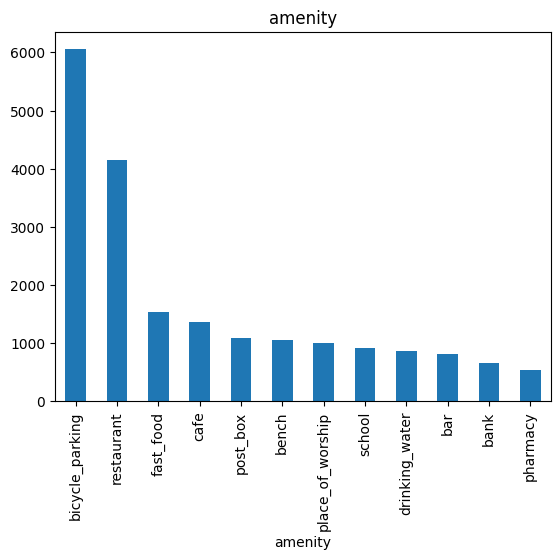

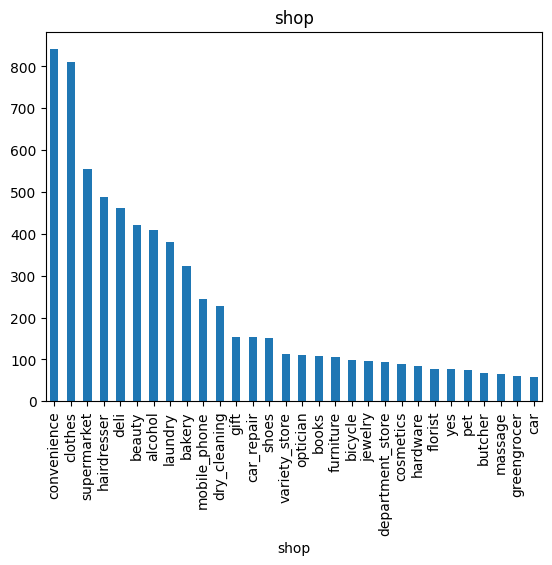

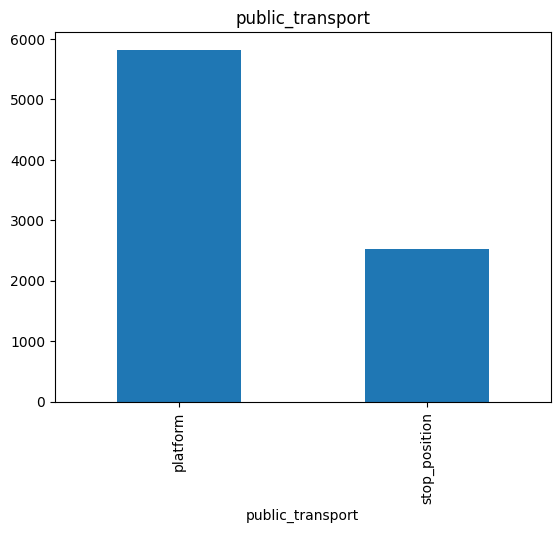

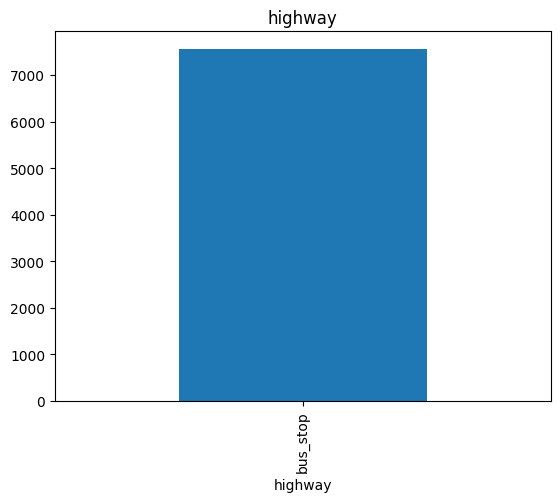

In [3]:
import matplotlib.pyplot as plt
def get_categories():
    return ["amenity", "shop", "public_transport", "highway"]
cols = pd.DataFrame()
for col in get_categories():
    cols = data[col].value_counts().cumsum()/data[col].value_counts().sum()
    cols = (cols>0.8).values.argmax()
    cols_to_plot = data[col].value_counts().iloc[:cols+1]
    cols_to_plot.plot(kind="bar")
    plt.title(col)
    plt.show()


### Exercise 4: Visualize POIs on Map
Define a function or class that, given a POI category name, shows a scatter plot of the locations of the POI types onto the New York municipality map, with a different color for each type.
- Are you able to identify areas with higher concentration of specific POI types?
- How can you better characterize the POI distributions?

**Info:** Use matplotlib `imshow()` to display the map image on an Axes object, then specify the Axes object using the `ax` argument in pandas methods.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20836\760055755.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


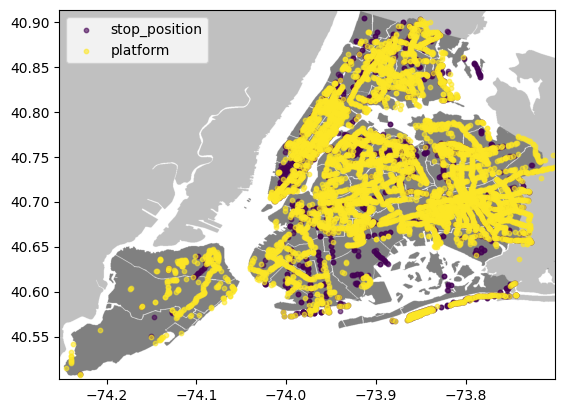

In [4]:
import numpy as np
import seaborn as sns

class Map:
    def __init__(self, df):
        self.df = df
        self.max_lon = df["@lon"].max()
        self.max_lat = df["@lat"].max()
        self.min_lon = df["@lon"].min()
        self.min_lat = df["@lat"].min()
    def plot_background(self):
        fig, ax = plt.subplots()
        img = plt.imread("New_York_City_MAP.png")
        ax.imshow(img, extent=[self.min_lon, self.max_lon, self.min_lat, self.max_lat])
        return ax
    def plot_points(self, ax, category=None, mask=None):
        target_df = self.df.loc[mask] if mask is not None else self.df
        types = target_df[category].dropna().unique()
        cmap = plt.cm.get_cmap('viridis')
        colors = cmap(np.linspace(0, 1, len(types)))
        for i, t in enumerate(types):
            df_t = target_df[target_df[category] == t]
            if df_t.empty:
                continue
            ax.scatter(df_t['@lon'], df_t['@lat'], color=colors[i], alpha=.6, label=t, s=10)
        ax.legend()
        ax.grid(False)
        return ax

def get_top_perc(df, perc = 0.8):
    comsum = df.cumsum()/df.sum()
    argmax = (comsum > perc).values.argmax()
    return df.iloc[:argmax + 1]

def show_category(df, category, p = 0.8):
    counts = df[category].value_counts()
    top_p = get_top_perc(counts, p)
    map = Map(df)
    ax = map.plot_background()
    mask = df[category].isin(top_p.index)

    map.plot_points(ax, category, mask)

show_category(data, "public_transport", 0.9)

### Exercise 5: Discretize POIs by Location
Define a function or class that splits the geographical position of POIs using a grid over the New York municipality. Assign each POI to the cell it belongs to. The result should be a DataFrame with a new `cell_id` column.

In [5]:
data["lat_cell"] = pd.cut(data["@lat"], 20, labels=False)
data["lon_cell"] = pd.cut(data["@lon"], 20, labels=False)
data["cell_id"] = data["lat_cell"] * 20 + data["lon_cell"]

data.head(10)

,id,@type,@lat,@lon,amenity,name,shop,public_transport,highway,lat_cell,lon_cell,cell_id
0,42432939,node,40.814104,-73.949623,NaN,NaN,NaN,stop_position,NaN,15,10,310
1,42448838,node,40.761647,-73.949864,NaN,NaN,NaN,stop_position,NaN,12,10,250
2,42723103,node,40.852182,-73.772677,ferry_terminal,Hart Island Ferry Terminal,NaN,NaN,NaN,16,17,337
3,42764076,node,40.867164,-73.882158,NaN,Botanical Garden,NaN,stop_position,NaN,17,13,353
4,42811266,node,40.704806,-73.772734,NaN,NaN,NaN,stop_position,NaN,9,17,197
5,42843048,node,40.745088,-73.864382,NaN,NaN,NaN,stop_position,NaN,11,14,234
6,42856866,node,40.659995,-73.765631,NaN,NaN,NaN,stop_position,NaN,7,17,157
7,42856870,node,40.659921,-73.765289,NaN,NaN,NaN,stop_position,NaN,7,17,157
8,42867098,node,40.776799,-73.782874,NaN,NaN,NaN,stop_position,NaN,13,17,277
9,100515086,node,40.753070,-73.976957,NaN,Grand Central Terminal,NaN,stop_position,NaN,12,9,249


### Exercise 6: POI Type Count per Cell
Create a new DataFrame containing:
- Index: `cell_id`
- Columns: POI types
- Values: count of occurrences of each type in each cell

In [6]:
def get_counts_per_cell(df, category, perc = 0.8):
    df_counts = df[category].value_counts()
    top_categories = get_top_perc(df_counts, perc).index
    mask = df[category].isin(top_categories)
    freq_df = df[mask]

    count_df = []
    for cell_id in range(20 ** 2):
        # Count only values of the selected category for this cell
        cell_data = freq_df.loc[freq_df['cell_id'] == cell_id, category].value_counts()
        cell_data.name = cell_id
        count_df.append(cell_data)

    cell_counts_df = pd.DataFrame(count_df).fillna(0)
    return cell_counts_df

amenities_df =get_counts_per_cell(data, "amenity",0.6)
amenities_df.head()


amenity,restaurant,post_box,fast_food,bicycle_parking,cafe,bench
0,2.0,2.0,1.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0


### Exercise 7: Correlation Analysis
For categories **amenities** and **shop**, compute the pairwise correlation between columns of the cell-type DataFrame and show it through a heatmap.
- Which POI types are more correlated? What does it mean?
- Which tuples are most correlated? Do they belong to the same category?

In [7]:
shops_df = get_counts_per_cell(data, "shop", 0.6)
shops_df.head()

shop,supermarket,convenience,gift,alcohol,clothes,bakery,beauty,laundry,hairdresser,deli,mobile_phone,dry_cleaning
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:

amenities_shops_df = pd.concat([amenities_df, shops_df], axis=1).fillna(0)
amenities_shops_df.corr().head()

,restaurant,post_box,fast_food,bicycle_parking,cafe,bench,supermarket,convenience,gift,alcohol,clothes,bakery,beauty,laundry,hairdresser,deli,mobile_phone,dry_cleaning
restaurant,1.000000,0.738146,0.892643,0.933327,0.977129,0.325605,0.854280,0.698709,0.748171,0.893299,0.897885,0.934591,0.641513,0.533456,0.702188,0.527927,0.697886,0.779390
post_box,0.738146,1.000000,0.791383,0.757908,0.751239,0.464872,0.831700,0.732534,0.572624,0.854463,0.640424,0.730414,0.744983,0.700626,0.764960,0.669046,0.747977,0.802623
fast_food,0.892643,0.791383,1.000000,0.823712,0.931877,0.463410,0.762383,0.707077,0.808271,0.856165,0.790148,0.759500,0.726217,0.557794,0.758824,0.574192,0.776886,0.822514
bicycle_parking,0.933327,0.757908,0.823712,1.000000,0.922268,0.381228,0.858209,0.633704,0.662442,0.873462,0.839809,0.888446,0.673453,0.522363,0.745809,0.490781,0.607225,0.793769
cafe,0.977129,0.751239,0.931877,0.922268,1.000000,0.407526,0.813572,0.694446,0.786491,0.901696,0.875035,0.874180,0.657689,0.508593,0.732542,0.480233,0.690048,0.813883


## 2.2 Data Exploration and Queries on Flight Delay Data

### Exercise 1: Load Dataset
Load the Flight Delay dataset using Pandas APIs.
- Use the `parse_dates` argument of `read_csv()` for timestamps so you can work with datetime values.

In [1]:
import pandas as pd
flight_data = pd.read_csv("831394006_T_ONTIME.csv", parse_dates=["FL_DATE"])
flight_data.head()

,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,TAIL_NUM,FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,...,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 32
0,2017-01-01,AA,19805,N787AA,1,12478,1247803,31703,JFK,"New York, NY",...,1209.0,27.0,0.0,NaN,27.0,0.0,0.0,0.0,0.0,NaN
1,2017-01-01,AA,19805,N783AA,2,12892,1289204,32575,LAX,"Los Angeles, CA",...,1809.0,42.0,0.0,NaN,34.0,0.0,8.0,0.0,0.0,NaN
2,2017-01-01,AA,19805,N791AA,4,12892,1289204,32575,LAX,"Los Angeles, CA",...,2040.0,42.0,0.0,NaN,7.0,0.0,0.0,0.0,35.0,NaN
3,2017-01-01,AA,19805,N391AA,5,11298,1129804,30194,DFW,"Dallas/Fort Worth, TX",...,1749.0,97.0,0.0,NaN,77.0,0.0,20.0,0.0,0.0,NaN
4,2017-01-01,AA,19805,N346AA,6,13830,1383002,33830,OGG,"Kahului, HI",...,642.0,42.0,0.0,NaN,0.0,0.0,42.0,0.0,0.0,NaN


### Exercise 2: Data Analysis
Use `info()` and `describe()` methods to analyze record distribution:
- Which type does each column have?
- Are there any missing values?
- How many unique carriers are present?
- How many unique airports are present?
- From which time interval were data collected?

In [2]:
flight_data.describe()

,FL_DATE,AIRLINE_ID,FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,CRS_DEP_TIME,...,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 32
count,450017,450017.000000,450017.000000,450017.000000,4.500170e+05,450017.000000,450017.000000,4.500170e+05,450017.000000,450017.000000,...,450017.000000,440746.000000,439645.000000,450017.000000,97699.000000,97699.000000,97699.000000,97699.000000,97699.000000,0.0
mean,2017-01-15 22:38:34.552561152,19900.483275,2079.643193,12698.267568,1.269830e+06,31738.603264,12698.024626,1.269805e+06,31738.404640,1327.757407,...,1506.278285,1487.332958,6.954484,0.019746,20.308836,3.368857,15.742495,0.079745,24.947492,NaN
min,2017-01-01 00:00:00,19393.000000,1.000000,10135.000000,1.013503e+06,30070.000000,10135.000000,1.013503e+06,30070.000000,5.000000,...,1.000000,1.000000,-98.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,2017-01-08 00:00:00,19690.000000,679.000000,11292.000000,1.129202e+06,30647.000000,11292.000000,1.129202e+06,30647.000000,917.000000,...,1120.000000,1108.000000,-15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,2017-01-16 00:00:00,19805.000000,1602.000000,12892.000000,1.289204e+06,31454.000000,12892.000000,1.289204e+06,31454.000000,1321.000000,...,1529.000000,1521.000000,-5.000000,0.000000,0.000000,0.000000,4.000000,0.000000,3.000000,NaN
75%,2017-01-24 00:00:00,20304.000000,3034.000000,14057.000000,1.405702e+06,32467.000000,14057.000000,1.405702e+06,32467.000000,1730.000000,...,1921.000000,1921.000000,11.000000,0.000000,17.000000,0.000000,20.000000,0.000000,31.000000,NaN
max,2017-01-31 00:00:00,21171.000000,7439.000000,16218.000000,1.621801e+06,35991.000000,16218.000000,1.621801e+06,35991.000000,2359.000000,...,2359.000000,2400.000000,1944.000000,1.000000,1934.000000,1934.000000,1457.000000,653.000000,1392.000000,NaN
std,NaN,385.381448,1722.700045,1534.326936,1.534324e+05,1286.063689,1534.246611,1.534244e+05,1285.791081,481.548320,...,501.853851,523.821795,49.595992,0.139126,60.649157,27.809756,32.328181,2.896287,47.850860,NaN


In [3]:
flight_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450017 entries, 0 to 450016
Data columns (total 33 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   FL_DATE                450017 non-null  datetime64[ns]
 1   UNIQUE_CARRIER         450017 non-null  object        
 2   AIRLINE_ID             450017 non-null  int64         
 3   TAIL_NUM               449378 non-null  object        
 4   FL_NUM                 450017 non-null  int64         
 5   ORIGIN_AIRPORT_ID      450017 non-null  int64         
 6   ORIGIN_AIRPORT_SEQ_ID  450017 non-null  int64         
 7   ORIGIN_CITY_MARKET_ID  450017 non-null  int64         
 8   ORIGIN                 450017 non-null  object        
 9   ORIGIN_CITY_NAME       450017 non-null  object        
 10  DEST_AIRPORT_ID        450017 non-null  int64         
 11  DEST_AIRPORT_SEQ_ID    450017 non-null  int64         
 12  DEST_CITY_MARKET_ID    450017 non-null  int6

### Exercise 3: Filter Canceled Flights
Remove all canceled flights from the dataset.

In [4]:
not_canceled = flight_data[flight_data["CANCELLED"] == 0].drop(columns=["CANCELLED", "CANCELLATION_CODE"])
not_canceled.sample(5)

,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,TAIL_NUM,FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,...,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 32
281865,2017-01-20,EV,20366,N753EV,5432,13871,1387102,33316,OMA,"Omaha, NE",...,5.0,1013,940.0,-33.0,NaN,NaN,NaN,NaN,NaN,NaN
19805,2017-01-02,DL,19790,N943AT,1699,11481,1148102,31481,ECP,"Panama City, FL",...,13.0,1419,1414.0,-5.0,NaN,NaN,NaN,NaN,NaN,NaN
410401,2017-01-29,AS,19930,N428AS,36,14747,1474703,30559,SEA,"Seattle, WA",...,4.0,1448,1442.0,-6.0,NaN,NaN,NaN,NaN,NaN,NaN
429418,2017-01-30,DL,19790,N930DL,43,12478,1247803,31703,JFK,"New York, NY",...,10.0,1824,1806.0,-18.0,NaN,NaN,NaN,NaN,NaN,NaN
159375,2017-01-11,OO,20304,N919SW,5182,12156,1215603,32156,HLN,"Helena, MT",...,8.0,910,917.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN


### Exercise 4: Basic Queries
Answer the following questions using any pandas method:
- How many flights had each carrier operated?
- For each carrier, compute the mean delay considering all possible reasons.

In [5]:
flights_per_carrier = not_canceled.groupby("UNIQUE_CARRIER").size().sort_values(ascending=False)
mean_delay_per_carrier = not_canceled.groupby(["UNIQUE_CARRIER"]).mean("CARRIER_DELAY").sort_values("CARRIER_DELAY", ascending=False)
mean_delay_per_carrier.head()

,AIRLINE_ID,FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,CRS_DEP_TIME,DEP_TIME,...,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 32
UNIQUE_CARRIER,,,,,,,,,,,,,,,,,,,,,
EV,20366.0,4413.665771,12276.019216,1.227605e+06,31559.449554,12277.386298,1.227742e+06,31561.616920,1312.821182,1331.048557,...,7.554183,1480.705945,1476.833195,13.173011,36.329407,1.368504,15.794439,0.000000,31.725109,NaN
DL,19790.0,1561.194623,12271.877084,1.227191e+06,31652.092335,12271.461141,1.227149e+06,31652.008445,1326.312541,1327.697440,...,7.479867,1512.160681,1484.198371,4.305279,30.858959,9.572160,16.836252,0.033901,21.964020,NaN
HA,19690.0,226.897731,12816.050815,1.281607e+06,32652.422020,12815.271652,1.281529e+06,32651.527005,1301.348354,1302.948066,...,6.837462,1430.886865,1420.531405,3.617181,29.941714,0.897143,0.251429,0.122286,14.113143,NaN
OO,20304.0,4875.851718,13114.223097,1.311425e+06,32082.654146,13114.555298,1.311458e+06,32084.241744,1322.660589,1339.594228,...,7.503253,1485.568703,1484.457945,12.528524,23.495640,4.633053,15.186582,0.100759,31.316244,NaN
UA,19977.0,993.303668,12826.367954,1.282639e+06,31663.272581,12826.584691,1.282661e+06,31664.282493,1298.839700,1306.521757,...,8.480582,1503.794195,1484.794477,4.911975,21.436417,2.568226,21.186162,0.016759,24.592458,NaN


### Exercise 5: Add New Columns
Add two new columns to your DataFrame:
- `weekday`: day of the week as integer (check Pandas `dayofweek` attribute)
- `delaydelta`: difference between arrival delay and departure delay

In [6]:
not_canceled["weekday"] = not_canceled["FL_DATE"].dt.weekday
not_canceled['delaydelta'] = not_canceled["ARR_DELAY"] - not_canceled["DEP_DELAY"]
not_canceled.sample(5)

,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,TAIL_NUM,FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,...,ARR_TIME,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 32,weekday,delaydelta
396491,2017-01-28,DL,19790,N316US,2790,14492,1449202,34492,RDU,"Raleigh/Durham, NC",...,948.0,-31.0,NaN,NaN,NaN,NaN,NaN,NaN,5,-26.0
128502,2017-01-09,WN,19393,N8654B,1603,15016,1501603,31123,STL,"St. Louis, MO",...,1553.0,23.0,18.0,0.0,5.0,0.0,0.0,NaN,0,5.0
40669,2017-01-03,WN,19393,N8319F,414,11259,1125903,30194,DAL,"Dallas, TX",...,1111.0,-24.0,NaN,NaN,NaN,NaN,NaN,NaN,1,-22.0
234854,2017-01-17,WN,19393,N484WN,1701,11259,1125903,30194,DAL,"Dallas, TX",...,1849.0,-6.0,NaN,NaN,NaN,NaN,NaN,NaN,1,-3.0
433981,2017-01-30,VX,21171,N524VA,737,11278,1127803,30852,DCA,"Washington, DC",...,2049.0,-21.0,NaN,NaN,NaN,NaN,NaN,NaN,0,-14.0


### Exercise 6: Delay vs Day of Week
Using any visualization tool, inspect arrival delay as a function of day of week. Can you find any correlation?

<Axes: title={'center': 'ARR_DELAY'}, xlabel='weekday'>

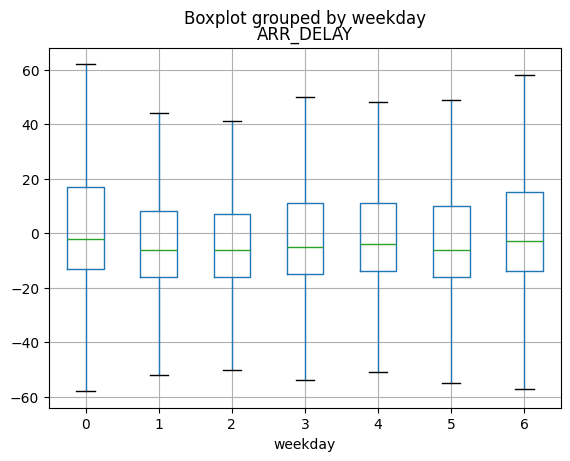

In [7]:
not_canceled.boxplot(by='weekday', column='ARR_DELAY', showfliers=False)

### Exercise 7: Weekend vs Weekday Delays
- For weekend days: compute mean arrival delay for each carrier
- For working days: compute mean arrival delay for each carrier
- Compare delays between weekdays and weekends for each company
- Can you identify companies delayed only on weekends or only on working days? Why?

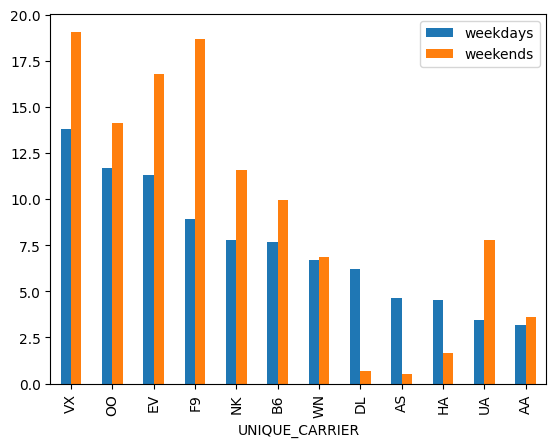

In [8]:
mean_arrival_delay_per_career_weekdays = not_canceled[not_canceled["weekday"] >= 2].groupby("UNIQUE_CARRIER")["ARR_DELAY"].mean().sort_values(ascending=False)
mean_arrival_delay_per_career_weekdends = not_canceled[not_canceled["weekday"] < 2].groupby("UNIQUE_CARRIER")["ARR_DELAY"].mean().sort_values(ascending=False)
mean_arrival_delay_per_career_weekdays.name = "weekdays"
mean_arrival_delay_per_career_weekdends.name = "weekends"
delays = pd.concat([mean_arrival_delay_per_career_weekdays, mean_arrival_delay_per_career_weekdends], axis=1).plot(kind="bar")


### Exercise 8: Multi-Index DataFrame
Create a Pandas DataFrame with multi-index composed of: `unique_carrier`, `origin`, `dest`, `fl_date`

In [9]:
new_df = not_canceled.set_index(["UNIQUE_CARRIER", "ORIGIN", "DEST", "FL_DATE"]).sort_index()
new_df.head()

AIRLINE_ID TAIL_NUM  FL_NUM  \
UNIQUE_CARRIER ORIGIN DEST FL_DATE                                   
AA             ABQ    DFW  2017-01-01       19805   N4XSAA    1282   
                           2017-01-01       19805   N3NRAA    2611   
                           2017-01-01       19805   N4WNAA    2402   
                           2017-01-02       19805   N4XKAA    2611   
                           2017-01-02       19805   N4XBAA    2402   

                                       ORIGIN_AIRPORT_ID  \
UNIQUE_CARRIER ORIGIN DEST FL_DATE                         
AA             ABQ    DFW  2017-01-01              10140   
                           2017-01-01              10140   
                           2017-01-01              10140   
                           2017-01-02              10140   
                           2017-01-02              10140   

                                       ORIGIN_AIRPORT_SEQ_ID  \
UNIQUE_CARRIER ORIGIN DEST FL_DATE                             
AA             ABQ    DFW  2017-01-01                1014003   
                           2017-01-01                1014003   
                           2017-01-01                1014003   
                           2017-01-02                1014003   
                           2017-01-02                1014003   

                                       ORIGIN_CITY_MARKET_ID ORIGIN_CITY_NAME  \
UNIQUE_CARRIER ORIGIN DEST FL_DATE                                              
AA             ABQ    DFW  2017-01-01                  30140  Albuquerque, NM   
                           2017-01-01                  30140  Albuquerque, NM   
                           2017-01-01                  30140  Albuquerque, NM   
                           2017-01-02                  30140  Albuquerque, NM   
                           2017-01-02                  30140  Albuquerque, NM   

                                       DEST_AIRPORT_ID  DEST_AIRPORT_SEQ_ID  \
UNIQUE_CARRIER ORIGIN DEST FL_DATE                                            
AA             ABQ    DFW  2017-01-01            11298              1129804   
                           2017-01-01            11298              1129804   
                           2017-01-01            11298              1129804   
                           2017-01-02            11298              1129804   
                           2017-01-02            11298              1129804   

                                       DEST_CITY_MARKET_ID  ... ARR_TIME  \
UNIQUE_CARRIER ORIGIN DEST FL_DATE                          ...            
AA             ABQ    DFW  2017-01-01                30194  ...   1029.0   
                           2017-01-01                30194  ...    744.0   
                           2017-01-01                30194  ...   1951.0   
                           2017-01-02                30194  ...    903.0   
                           2017-01-02                30194  ...   2036.0   

                                       ARR_DELAY  CARRIER_DELAY  \
UNIQUE_CARRIER ORIGIN DEST FL_DATE                                
AA             ABQ    DFW  2017-01-01      -18.0            NaN   
                           2017-01-01       -5.0            NaN   
                           2017-01-01       29.0            0.0   
                           2017-01-02       74.0            0.0   
                           2017-01-02       76.0            2.0   

                                       WEATHER_DELAY  NAS_DELAY  \
UNIQUE_CARRIER ORIGIN DEST FL_DATE                                
AA             ABQ    DFW  2017-01-01            NaN        NaN   
                           2017-01-01            NaN        NaN   
                           2017-01-01            0.0        3.0   
                           2017-01-02           69.0        5.0   
                           2017-01-02            0.0        0.0   

                                       SECURITY_DELAY  LATE_AIRCRAFT_DELAY  \
UNIQU

### Exercise 9: Specific Flights Query
For flights operated by American Airlines (AA) and Delta Airlines (DL), departing from Los Angeles International Airport (LAX), for each date, display the departure time and delay.

In [10]:
new_df.loc[(["AA", "DL"], ["LAX"]),["DEP_TIME", "DEP_DELAY"]].head(10)

DEP_TIME  DEP_DELAY
UNIQUE_CARRIER ORIGIN DEST FL_DATE                        
AA             LAX    ATL  2017-01-01    1051.0       16.0
                           2017-01-01    1747.0      137.0
                           2017-01-02    1548.0       18.0
                           2017-01-02    2230.0       40.0
                           2017-01-02    1055.0       20.0
                           2017-01-03    2150.0        0.0
                           2017-01-03    1050.0       15.0
                           2017-01-03    1529.0       -1.0
                           2017-01-04    1526.0       -4.0
                           2017-01-04    2149.0       -1.0

### Exercise 10: First Week Queries
For each flight that flew in the first week of the month with LAX as destination airport, compute the mean arrival delay.

In [11]:
new_df.loc[pd.IndexSlice[:, :, "LAX", "2017-01-01": "2017-01-08"],:].groupby("FL_NUM")["ARR_DELAY"].mean()

FL_NUM
1        0.000000
2       60.000000
4       11.625000
5        2.875000
7       16.750000
          ...    
6344    47.000000
6354    60.000000
6522    49.666667
6563    -8.000000
6710    10.000000
Name: ARR_DELAY, Length: 1105, dtype: float64

### Exercise 11: Pivot Table - Flights per Carrier/Day
Create a pivot table with:
- Number of departed flights
- Rows: carriers
- Columns: day of week

Then compute pairwise correlation between carriers and show on a heatmap.
- What does this correlation matrix represent?
- Can you find any carrier with different flight plans?

weekday               0        1        2        3        4        5        6
UNIQUE_CARRIER                                                               
AA              12035.0  11457.0   9651.0   9854.0   9820.0   7905.0  11430.0
AS               2440.0   2261.0   1806.0   1935.0   1953.0   1762.0   2297.0
B6               4063.0   3942.0   3143.0   3258.0   3169.0   2643.0   3859.0
DL              12157.0  11512.0   9248.0   9695.0   9521.0   6492.0  10406.0
EV               5935.0   5649.0   4627.0   4923.0   4774.0   2905.0   5065.0
F9               1239.0   1214.0    976.0    983.0    986.0    955.0   1245.0
HA                987.0    966.0    791.0    802.0    864.0    826.0   1022.0
NK               1954.0   1970.0   1616.0   1610.0   1563.0   1470.0   1946.0
OO               8321.0   7912.0   6413.0   6631.0   6667.0   4913.0   7409.0
UA               7498.0   6883.0   5384.0   5956.0   5920.0   3964.0   6566.0
VX                986.0    914.0    741.0    791.0    792.0    5

<Axes: xlabel='UNIQUE_CARRIER', ylabel='UNIQUE_CARRIER'>

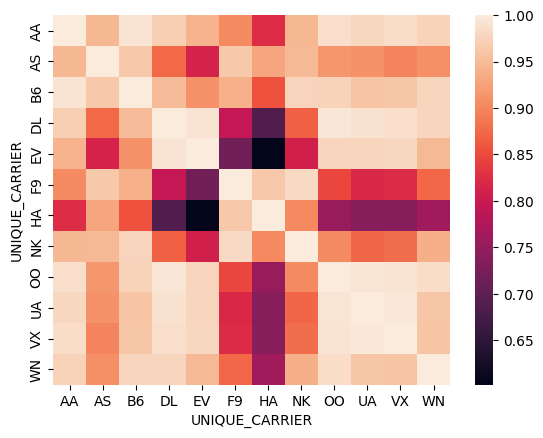

In [26]:
import seaborn as sns
target_df = not_canceled.groupby(["UNIQUE_CARRIER","weekday"])["FL_NUM"].count()
pivot_table = pd.pivot_table(target_df.reset_index(), values="FL_NUM", index="UNIQUE_CARRIER", columns="weekday", fill_value=0)
print(pivot_table)
sns.heatmap(pivot_table.T.corr())

### Exercise 12: Pivot Table - Average Delay per Carrier/Day
Create a pivot table with:
- Average arrival delay
- Rows: carriers
- Columns: day of week

Then compute pairwise correlation between carriers and show on a heatmap.
- What does this correlation matrix represent?
- Can you find any carrier with different delay behaviors?

weekday                 0          1          2          3          4  \
UNIQUE_CARRIER                                                          
AA               6.166653   0.899956  -0.733742   1.167107   2.849597   
AS               1.744243  -0.795982   5.797327   4.365145   1.041602   
B6              12.745117   7.053235   1.656450  -0.285054   4.651251   
DL               5.652933  -4.535590  -5.432658  -4.369801  -2.084867   
EV              22.496612  10.791889   5.689274   8.576665   9.070754   
F9              23.677445  13.563380   8.149744  11.303772   9.160569   
HA               2.127660   1.141969   1.416984   1.624220   8.109954   
NK              15.736303   7.421534   2.780186   7.838409   6.500963   
OO              17.011347  11.123554  10.783691  15.675984  12.453080   
UA               9.877057   5.498687   1.972103   1.998656   0.034880   
VX              18.258567  19.964444  15.483039  14.533079   9.178117   
WN              10.891738   2.835325   3.760267   8

<Axes: xlabel='UNIQUE_CARRIER', ylabel='UNIQUE_CARRIER'>

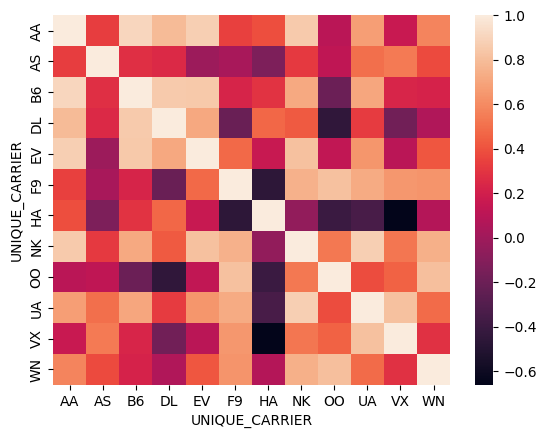

In [27]:
average_delay_per_carrier_weekday = not_canceled.groupby(["UNIQUE_CARRIER", "weekday"])["ARR_DELAY"].mean().unstack(fill_value=0)
print(average_delay_per_carrier_weekday)
sns.heatmap(average_delay_per_carrier_weekday.T.corr())

### Exercise 13: Delta-Delay by Carrier and Weekday
Using a pivot table, for carriers **HA**, **DL**, **AA**, and **AS**, compute the average `delaydelta` for each day of the week. Display results on a line plot with one line per carrier and weekday on the x-axis.

Text(0.5, 0, 'Weekday')

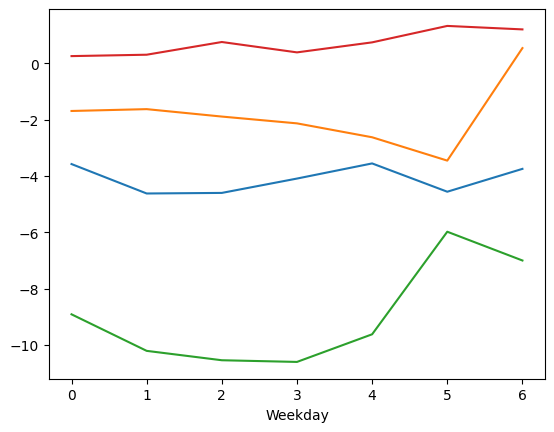

In [21]:
import matplotlib.pyplot as plt
delta_delay_per_carrier_weekday = not_canceled[not_canceled["UNIQUE_CARRIER"].isin(["HA", "DL", "AA", "AS"])].groupby(["UNIQUE_CARRIER", "weekday"])["delaydelta"].mean().unstack(fill_value = 0)
plt.plot(delta_delay_per_carrier_weekday.T)
plt.xlabel("Weekday")